<a href="https://colab.research.google.com/github/Gaddy01/Time-Series-Forcasting/blob/main/notebooks/03_Forecasting_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3: Related Work and Model Selection

Previous research has extensively investigated recurrent neural networks for cellular traffic forecasting. Surveys of cellular traffic prediction identify RNN-based methods as an important approach for modelling temporal dependencies, while noting limitations of standard RNNs in learning long-term dependencies. LSTM and GRU were developed to improve the handling of such dependencies.[1]

Santos et al. directly investigated LSTM and GRU using the Telecom Italia Milan dataset used in this study and found that both models were effective in modelling Internet activity and seasonality, with performance varying across geographical clusters.[2]

Based on this literature and the strong short-term, daily, and weekly temporal dependencies identified during EDA, this study selects three recurrent architectures: standard RNN, GRU, and LSTM. These models allow us to investigate whether progressively different mechanisms for handling temporal information lead to differences in forecasting performance.

## 3.1 Model Selection Approach

The exploratory analysis showed that mobile Internet traffic has strong temporal structure. In particular, Square 5161 showed high autocorrelation at short lags, with an autocorrelation of approximately 0.987 at 10 minutes and 0.939 at one hour. Strong dependencies were also observed at 24 hours and 7 days, with autocorrelations of approximately 0.893 and 0.929 respectively.

These characteristics suggest that sequential models capable of learning temporal dependencies are appropriate for the forecasting task.

Based on the exploratory analysis, the relevant literature, and the sequential modelling architectures covered in the course, three models were selected:

* **Standard Recurrent Neural Network (RNN)**
* **Gated Recurrent Unit (GRU)**
* **Long Short-Term Memory (LSTM)**

These models belong to the same broad recurrent family but use different mechanisms for processing and retaining information across a sequence. This provides a controlled comparison of different recurrent architectures.

## 3.2 Standard RNN

A standard Recurrent Neural Network processes observations sequentially and maintains a hidden state that carries information from previous time steps.

RNN was selected as the simplest recurrent architecture and provides a useful baseline for the forecasting task. Its sequential structure is appropriate for the strong short-term temporal dependence observed in the traffic data.

However, standard RNNs can have difficulty learning long-term dependencies because of issues such as vanishing or exploding gradients. This may be particularly relevant to this dataset because the EDA identified strong relationships at daily and weekly lags.

Therefore, RNN provides a baseline against which the gated architectures can be compared.

## 3.3 Gated Recurrent Unit (GRU)

GRU is a gated recurrent architecture that uses update and reset mechanisms to control the flow of information through the network.

GRU was selected because it provides a recurrent architecture designed to improve the handling of longer-term dependencies while generally using fewer parameters than LSTM.

This makes GRU an interesting middle ground between the simpler RNN and the more complex LSTM. Its performance will help determine whether the additional gating mechanisms provide an advantage over the standard RNN for this forecasting problem.

## 3.4 Long Short-Term Memory (LSTM)

LSTM is a gated recurrent architecture that uses memory cells and gates to control which information is retained, updated, and discarded.

LSTM was selected because it is widely used for sequential forecasting and has also been applied specifically to mobile Internet traffic forecasting. Previous research using the Telecom Italia Milan dataset found LSTM effective for modelling Internet activity and seasonality.

The strong temporal dependencies and daily and weekly patterns observed during EDA therefore provide a strong motivation for testing LSTM.

Its main limitation compared with simpler recurrent models is its greater architectural and computational complexity.

## 3.5 Comparison of Selected Models

| Model | Architecture                              | Main reason for selection                               |
| ----- | ----------------------------------------- | ------------------------------------------------------- |
| RNN   | Standard recurrent network                | Simple sequential baseline                              |
| GRU   | Gated recurrent network                   | Gated memory with a relatively simple architecture      |
| LSTM  | Gated recurrent network with memory cells | Strong capability for learning longer-term dependencies |

The three architectures allow us to investigate whether progressively more sophisticated mechanisms for handling temporal information improve one-step-ahead traffic forecasting.

The comparison will focus on both predictive performance and computational cost rather than assuming in advance that the most complex model will perform best.

## 3.6 Forecasting Experimental Plan

All three models will initially use the same forecasting setup to ensure a fair comparison.

The task is **one-step-ahead forecasting**, where a sequence of previous Internet traffic observations is used to predict the next 10-minute observation.

The initial input will be **univariate**, using the historical Internet traffic of each geographical area. A sequence length of 144 observations, corresponding to 24 hours, will be used as the initial configuration because the exploratory analysis identified a strong daily pattern.

Sequence length and model-specific hyperparameters will then be adjusted through iterative experimentation. Each experiment will be evaluated on the validation period, with the final selected configurations evaluated on the held-out test period.

The three geographical areas selected for forecasting are:

* Square 5161
* Square 5059
* Square 5259

The final test period will be **December 16–22**, following the assignment requirements.

The experiments will record model configuration, validation performance, training time, and the reasoning behind subsequent parameter changes.

## References

1. Wang, Z. W. et al. (2024). *A Survey on Deep Learning for Cellular Traffic Prediction.*
2. Santos, G. L. et al. (2022). *Predicting Short-Term Mobile Internet Traffic from Internet Activity Using Recurrent Neural Networks. International Journal of Network Management.*


# Task 4: Forecasting Implementation

## 4.1 Forecasting Objective and Protocol

The objective is to perform one-step-ahead forecasting of mobile Internet traffic for the three geographical areas with the highest total Internet activity identified during the exploratory analysis: Squares 5161, 5059, and 5259.

For each geographical area, the models use a sequence of historical Internet traffic observations to predict the traffic value at the next 10-minute interval.

The three models evaluated are:

* Standard Recurrent Neural Network (RNN)
* Gated Recurrent Unit (GRU)
* Long Short-Term Memory (LSTM)

The models will be trained and evaluated using the same forecasting setup to allow a fair comparison.

### Forecasting Setup

* **Target variable:** Internet activity
* **Forecast horizon:** 1 step ahead (10 minutes)
* **Input:** Historical Internet activity of the target geographical area
* **Initial sequence length:** 144 observations (24 hours)
* **Areas:** 5161, 5059, 5259
* **Validation period:** December 9–15, 2013
* **Test period:** December 16–22, 2013

The test period is kept separate from model selection and hyperparameter tuning. Model configurations will be selected using the training and validation periods, after which the final models will be evaluated on the held-out test period.

The initial sequence length of 144 observations represents 24 hours because the dataset contains one observation every 10 minutes. This provides one complete daily cycle as the initial historical context. Sequence length will be investigated during the iterative experimentation process because the exploratory analysis also identified longer-term temporal dependencies.


In [28]:
import os
import gc
import time
import random
from pathlib import Path
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Python and libraries loaded successfully.")
print("TensorFlow version:", tf.__version__)

Python and libraries loaded successfully.
TensorFlow version: 2.20.0


To make our experiments more reproducible, let's set random seeds

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


## 4.2 Load the three selected areas

Let's now mount the google drive and define the project paths

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
DRIVE_ROOT = Path("/content/drive/MyDrive")

PROJECT_DIR = DRIVE_ROOT / "ML Techniques I" / "Formative 1"

DATA_DIR = PROJECT_DIR / "data"
RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
LOGS_DIR = RESULTS_DIR / "logs"

MASTER_PARQUET = (DATA_DIR / "telecom_milan_master.parquet")

MODEL_DIR = "/content/drive/MyDrive/ML Techniques I/Formative 1/models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Project directory:")
print(PROJECT_DIR)

print("\nMaster dataset:")
print(MASTER_PARQUET)

print("\nMaster dataset exists:", MASTER_PARQUET.exists())

Project directory:
/content/drive/MyDrive/ML Techniques I/Formative 1

Master dataset:
/content/drive/MyDrive/ML Techniques I/Formative 1/data/telecom_milan_master.parquet

Master dataset exists: True


Let's now define forecasting configuration and Load only the required data

In [5]:
TARGET_SQUARES = [5161, 5059, 5259]

TARGET_COLUMN = "internet"

SEQUENCE_LENGTH = 144
FORECAST_HORIZON = 1

print("Target squares:", TARGET_SQUARES)
print("Target variable:", TARGET_COLUMN)
print("Sequence length:", SEQUENCE_LENGTH)
print("Forecast horizon:", FORECAST_HORIZON)

Target squares: [5161, 5059, 5259]
Target variable: internet
Sequence length: 144
Forecast horizon: 1


In [12]:
TARGET_COLUMNS = ["square_id", "timestamp", "internet"]

load_start = time.perf_counter()

traffic = pd.read_parquet(
    MASTER_PARQUET,
    columns=TARGET_COLUMNS,
    filters=[("square_id", "in", TARGET_SQUARES)]
)

load_time = time.perf_counter() - load_start

print(f"Loaded rows: {len(traffic):,}")
print(f"Loading time: {load_time:.2f} seconds")
print(f"Memory usage: {traffic.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Loaded rows: 26,784
Loading time: 22.67 seconds
Memory usage: 0.36 MB


We notice that this is dramatically smaller than loading the entire 89-million-row dataset. We only loaded three columns (square_id, timestamp, internet) across three geographical areas.

let's now Convert the timestamp and Verify the three geographical areas

In [13]:
traffic["timestamp"] = pd.to_datetime(traffic["timestamp"], unit="ms")

traffic = (traffic.sort_values(["square_id", "timestamp"]).reset_index(drop=True))

print(traffic.dtypes)
print()
print(traffic.head())

square_id             int16
timestamp    datetime64[ns]
internet            float32
dtype: object

   square_id           timestamp    internet
0       5059 2013-10-31 23:00:00  537.570496
1       5059 2013-10-31 23:10:00  646.569031
2       5059 2013-10-31 23:20:00  569.782410
3       5059 2013-10-31 23:30:00  800.599609
4       5059 2013-10-31 23:40:00  517.068420


In [14]:
square_summary = (
    traffic
    .groupby("square_id")
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        observations=("internet", "size"),
        missing_count=("internet", lambda x: x.isna().sum())
    )
    .reset_index()
)

square_summary["missing_percentage"] = (
    square_summary["missing_count"]
    / square_summary["observations"]
    * 100
)

square_summary

,square_id,start_time,end_time,observations,missing_count,missing_percentage
0,5059,2013-10-31 23:00:00,2014-01-01 22:50:00,8928,0,0.0
1,5161,2013-10-31 23:00:00,2014-01-01 22:50:00,8928,0,0.0
2,5259,2013-10-31 23:00:00,2014-01-01 22:50:00,8928,0,0.0


## 4.3 Time Zone Conversion: UTC to Milan Local Time

In [15]:
# Check the number of observations by calendar date

square_5161 = (traffic[traffic["square_id"] == 5161].sort_values("timestamp").copy())

daily_counts = (
    square_5161
    .assign(date=square_5161["timestamp"].dt.date)
    .groupby("date")
    .size()
)

print("Number of calendar dates:", len(daily_counts))

print("\nFirst 5 dates:")
print(daily_counts.head())

print("\nLast 5 dates:")
print(daily_counts.tail())

print("\nDates with 144 observations:")
print((daily_counts == 144).sum())

Number of calendar dates: 63

First 5 dates:
date
2013-10-31      6
2013-11-01    144
2013-11-02    144
2013-11-03    144
2013-11-04    144
dtype: int64

Last 5 dates:
date
2013-12-28    144
2013-12-29    144
2013-12-30    144
2013-12-31    144
2014-01-01    138
dtype: int64

Dates with 144 observations:
61


In [16]:
# Convert Unix timestamps to Milan local time

traffic["timestamp"] = (
    pd.to_datetime(traffic["timestamp"], unit="ms", utc=True)
    .dt.tz_convert("Europe/Rome")
    .dt.tz_localize(None)
)

traffic = (traffic.sort_values(["square_id", "timestamp"]).reset_index(drop=True))

print("First timestamp:")
print(traffic["timestamp"].min())

print("\nLast timestamp:")
print(traffic["timestamp"].max())

First timestamp:
2013-11-01 00:00:00

Last timestamp:
2014-01-01 23:50:00


The timestamps in the dataset are Unix timestamps and were initially converted to **UTC**. Since the data represents mobile network activity in Milan, the timestamps were converted from UTC to the **Europe/Rome** time zone and then stored as timezone-naive local timestamps. This corrects the one-hour offset observed in the initial timestamps and aligns the observations with the local Milan calendar. After conversion, each geographical area contains 62 complete days with 144 observations per day, corresponding to the 10-minute sampling interval of the dataset.


## 4.4 Train / Validation / test split

Let's now establish the chronological splits and create them with the dataset

In [17]:
TRAIN_START = pd.Timestamp("2013-11-01 00:00:00")
TRAIN_END = pd.Timestamp("2013-12-08 23:50:00")

VAL_START = pd.Timestamp("2013-12-09 00:00:00")
VAL_END = pd.Timestamp("2013-12-15 23:50:00")

TEST_START = pd.Timestamp("2013-12-16 00:00:00")
TEST_END = pd.Timestamp("2013-12-22 23:50:00")

print("Training:")
print(TRAIN_START, "to", TRAIN_END)

print("\nValidation:")
print(VAL_START, "to", VAL_END)

print("\nTest:")
print(TEST_START, "to", TEST_END)

Training:
2013-11-01 00:00:00 to 2013-12-08 23:50:00

Validation:
2013-12-09 00:00:00 to 2013-12-15 23:50:00

Test:
2013-12-16 00:00:00 to 2013-12-22 23:50:00


In [18]:
train_df = traffic[
    (traffic["timestamp"] >= TRAIN_START) &
    (traffic["timestamp"] <= TRAIN_END)
].copy()

val_df = traffic[
    (traffic["timestamp"] >= VAL_START) &
    (traffic["timestamp"] <= VAL_END)
].copy()

test_df = traffic[
    (traffic["timestamp"] >= TEST_START) &
    (traffic["timestamp"] <= TEST_END)
].copy()

print("Training rows:", f"{len(train_df):,}")
print("Validation rows:", f"{len(val_df):,}")
print("Test rows:", f"{len(test_df):,}")

Training rows: 16,416
Validation rows: 3,024
Test rows: 3,024


## 4.5 Normalization & Sequence Construction

Let's first create a function that converts a univariate time series into supervised learning sequences for one-step-ahead forecasting.

- X: previous `sequence_length` observations
- y: observation immediately following X

In [19]:
def create_sequences(values, sequence_length):
    X = []
    y = []

    for i in range(sequence_length, len(values)):
        X.append(values[i - sequence_length:i])
        y.append(values[i])

    return np.array(X), np.array(y)

def get_square_series(df, square_id):
    series = (
        df[df["square_id"] == square_id]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    return series

Before creating the final sequences, we need to normalize the values. We will use `StandardScaler`:

$$ z = \frac {x-μ} σ $$

where:
- μ = training-set mean
- σ = training-set standard deviation

The scaler will be fitted only on the training data. This is important because using validation or test data to calculate the mean and standard deviation would introduce information from the future into the training process.

In [20]:
scalers = {}

train_scaled = {}
val_scaled = {}
test_scaled = {}

for square_id in TARGET_SQUARES:

    train_values = (get_square_series(train_df, square_id)["internet"].to_numpy().reshape(-1, 1))
    val_values = (get_square_series(val_df, square_id)["internet"].to_numpy().reshape(-1, 1))
    test_values = (get_square_series(test_df, square_id)["internet"].to_numpy().reshape(-1, 1))

    scaler = StandardScaler()

    train_scaled[square_id] = (scaler.fit_transform(train_values).flatten())
    val_scaled[square_id] = (scaler.transform(val_values).flatten())
    test_scaled[square_id] = (scaler.transform(test_values).flatten())

    scalers[square_id] = scaler

    print(f"\nSquare {square_id}")
    print(f"Training mean: {scaler.mean_[0]:.4f}")
    print(f"Training std: {scaler.scale_[0]:.4f}")


Square 5161
Training mean: 1511.4172
Training std: 1389.7002

Square 5059
Training mean: 1342.6043
Training std: 956.6394

Square 5259
Training mean: 1314.1243
Training std: 1119.2854


Next, we're going to save the Scaler information

In [ ]:
SCALER_DIR = "/content/formative1/scalers"
os.makedirs(SCALER_DIR, exist_ok=True)

for square_id in [5161, 5059, 5259]:

    scaler_path = os.path.join(SCALER_DIR, f"scaler_{square_id}.pkl")

    joblib.dump(scalers[square_id], scaler_path)

    print(f"Scaler saved to: {scaler_path}")

Scaler saved to: /content/formative1/scalers/scaler_5161.pkl
Scaler saved to: /content/formative1/scalers/scaler_5059.pkl
Scaler saved to: /content/formative1/scalers/scaler_5259.pkl


Let's now create the training sequences by turning the normalized training series into model inputs.

In [21]:
train_sequences = {}

for square_id in TARGET_SQUARES:

    X_train, y_train = create_sequences(train_scaled[square_id], SEQUENCE_LENGTH)

    # Add the feature dimension required by Keras RNN layers
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

    y_train = y_train.reshape(-1, 1)

    train_sequences[square_id] = {
        "X": X_train,
        "y": y_train
    }

    print(f"Square {square_id}: X_train = {X_train.shape}, y_train = {y_train.shape}")

Square 5161: X_train = (5328, 144, 1), y_train = (5328, 1)
Square 5059: X_train = (5328, 144, 1), y_train = (5328, 1)
Square 5259: X_train = (5328, 144, 1), y_train = (5328, 1)


Now, we are going to create the validation sequences. For this, we need to include the final 144 training observations as historical context.

In [22]:
val_sequences = {}

for square_id in TARGET_SQUARES:

    combined_values = np.concatenate([train_scaled[square_id][-SEQUENCE_LENGTH:], val_scaled[square_id]])

    X_val, y_val = create_sequences(combined_values, SEQUENCE_LENGTH)
    X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)

    y_val = y_val.reshape(-1, 1)

    val_sequences[square_id] = {
        "X": X_val,
        "y": y_val
    }

    print(f"Square {square_id}: X_val = {X_val.shape}, y_val = {y_val.shape}")

Square 5161: X_val = (1008, 144, 1), y_val = (1008, 1)
Square 5059: X_val = (1008, 144, 1), y_val = (1008, 1)
Square 5259: X_val = (1008, 144, 1), y_val = (1008, 1)


Next, let's create test sequences.

Exactly the same principle applies to the test period. The first test prediction needs the final 24 hours of validation data as historical context.

In [23]:
test_sequences = {}

for square_id in TARGET_SQUARES:

    combined_values = np.concatenate([val_scaled[square_id][-SEQUENCE_LENGTH:], test_scaled[square_id]])

    X_test, y_test = create_sequences(combined_values, SEQUENCE_LENGTH)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    y_test = y_test.reshape(-1, 1)

    test_sequences[square_id] = {
        "X": X_test,
        "y": y_test
    }

    print(f"Square {square_id}: X_test = {X_test.shape}, y_test = {y_test.shape}")

Square 5161: X_test = (1008, 144, 1), y_test = (1008, 1)
Square 5059: X_test = (1008, 144, 1), y_test = (1008, 1)
Square 5259: X_test = (1008, 144, 1), y_test = (1008, 1)


Finally, let's Verify the sequence dates

In [24]:
for square_id in TARGET_SQUARES:

    val_series = get_square_series(val_df, square_id)
    test_series = get_square_series(test_df, square_id)

    print(f"\nSquare {square_id}")
    print("First validation target:", val_series["timestamp"].iloc[0])
    print("Last validation target:", val_series["timestamp"].iloc[-1])
    print("First test target:", test_series["timestamp"].iloc[0])
    print("Last test target:", test_series["timestamp"].iloc[-1])


Square 5161
First validation target: 2013-12-09 00:00:00
Last validation target: 2013-12-15 23:50:00
First test target: 2013-12-16 00:00:00
Last test target: 2013-12-22 23:50:00

Square 5059
First validation target: 2013-12-09 00:00:00
Last validation target: 2013-12-15 23:50:00
First test target: 2013-12-16 00:00:00
Last test target: 2013-12-22 23:50:00

Square 5259
First validation target: 2013-12-09 00:00:00
Last validation target: 2013-12-15 23:50:00
First test target: 2013-12-16 00:00:00
Last test target: 2013-12-22 23:50:00


## 4.6 Model creation & results saving functions

Let's start by defining the common training configuration so that the models' performance can be compared fairly.

In [ ]:
# Common Training Configuration

SEQUENCE_LENGTH = 144

INITIAL_UNITS = 64

LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 50

EARLY_STOPPING_PATIENCE = 5

In [ ]:
# Optimizer and Early Stopping definition

def create_optimizer():
    return tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    )

def create_early_stopping():
    return EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True
    )

In [ ]:
# Flexible Model Builder (including Deep Models)

def build_model(model_type, layer_units):
    """
    Build an RNN, GRU, or LSTM model with a flexible
    number of recurrent layers.

    Parameters
    ----------
    model_type : str
        "RNN", "GRU", or "LSTM"

    layer_units : list of int
        Number of units in each recurrent layer.
        Example:
            [128]              -> one layer
            [128, 128]         -> two layers
            [128, 128, 128]    -> three layers
    """

    model = Sequential()

    # Select recurrent layer type
    if model_type == "RNN":
        recurrent_layer = SimpleRNN

    elif model_type == "GRU":
        recurrent_layer = GRU

    elif model_type == "LSTM":
        recurrent_layer = LSTM

    else:
        raise ValueError("model_type must be 'RNN', 'GRU', or 'LSTM'")

    # Add recurrent layers
    for i, units in enumerate(layer_units):

        is_last_layer = (i == len(layer_units) - 1)

        model.add(
            recurrent_layer(
                units=units,
                return_sequences=not is_last_layer,
                input_shape=(
                    SEQUENCE_LENGTH,
                    1
                ) if i == 0 else None
            )
        )

    # Output layer
    model.add(Dense(1))

    # Compile
    model.compile(optimizer=create_optimizer(), loss="mse")

    return model

Initially, we will deliberately using **one recurrent layer + one Dense output layer**. We will then later investigate whether increasing the number of units, changing sequence length, or changing other hyperparameters improves validation performance.

Let's now define the evaluation function: Because the models train on standardized values, we need to convert predictions back to the original Internet-traffic scale before calculating MAE, RMSE, and MAPE.

In [ ]:
# Calculate forecasting metrics on the original traffic scale.

def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Avoid division by zero in MAPE
    non_zero = y_true != 0

    if np.any(non_zero):
        mape = np.mean(
            np.abs((y_true[non_zero] - y_pred[non_zero])/ y_true[non_zero])
        ) * 100
    else:
        mape = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [ ]:
RESULTS_DIR = "/content/drive/MyDrive/ML Techniques I/Formative 1/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

RESULTS_FILE = os.path.join(RESULTS_DIR, "training_results.csv")

In [ ]:
def save_training_result(result):
    """
    Append one experiment's results to the training results CSV.
    """

    result_df = pd.DataFrame([result])

    if os.path.exists(RESULTS_FILE):
        # Load existing results and append the new experiment
        existing_df = pd.read_csv(RESULTS_FILE)
        updated_df = pd.concat([existing_df, result_df], ignore_index=True)
    else:
        # Create a new file
        updated_df = result_df

    updated_df.to_csv(RESULTS_FILE, index=False)

    print(f"Results saved to: {RESULTS_FILE}")

In [ ]:
# General Training Function

def train_experiment(model_type, square_id, layer_units, batch_size=BATCH_SIZE, epochs=EPOCHS):
    """
    Train and validate one forecasting experiment.
    """

    print("\n" + "=" * 70)
    architecture = (f"{model_type}("+ ", ".join(map(str, layer_units))+ ")")
    print(f"Training {architecture} - Square {square_id}")
    print("=" * 70)

    # Build model
    model = build_model(model_type=model_type, layer_units=layer_units)

    # Get training and validation data
    X_train = train_sequences[square_id]["X"]
    y_train = train_sequences[square_id]["y"]

    X_val = val_sequences[square_id]["X"]
    y_val = val_sequences[square_id]["y"]

    # Early stopping
    early_stopping = create_early_stopping()

    # Train model and measure training time
    start_time = time.perf_counter()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1,
        shuffle=False
    )

    # After training, emediatly save the model
    model_path = os.path.join(MODEL_DIR, f"{model_type}_{square_id}.keras")
    model.save(model_path)
    print(f"Model saved to: {model_path}")

    training_time = time.perf_counter() - start_time

    # Validation Predictions
    y_val_pred_scaled = model.predict(X_val, verbose=0).flatten()
    y_val_scaled = y_val.flatten()

    # Convert back to original traffic scale
    scaler = scalers[square_id]

    y_val_original = scaler.inverse_transform(y_val_scaled.reshape(-1, 1)).flatten()
    y_val_pred_original = scaler.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()

    # Calculate validation metrics
    metrics = calculate_metrics(y_val_original, y_val_pred_original)

    # Retain the best epoch
    best_epoch = (np.argmin(history.history["val_loss"]) + 1)

    # Results
    print("\nTraining completed.")
    print(f"Training time: {training_time:.2f} seconds")
    print(f"Epochs completed: {len(history.history['loss'])}")
    print(f"Best epoch: {best_epoch}")

    print("\nValidation metrics:")
    print(f"MAE:  {metrics['MAE']:.4f}")
    print(f"RMSE: {metrics['RMSE']:.4f}")
    print(f"MAPE: {metrics['MAPE']:.2f}%")

    results = {
        "square_id": square_id,
        "model": model,
        "model_type": model_type,
        "layer_units": layer_units,
        "learning_rate": LEARNING_RATE,
        "batch_size": batch_size,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "MAPE": metrics["MAPE"],
        "training_time_seconds": training_time,
        #"y_val_original": y_val_original,
        #"y_val_pred_original": y_val_pred_original,
        "epochs": epochs,
        "epochs_completed": len(history.history["loss"]),
        "best_epoch": best_epoch
    }

    save_training_result(results)

    return results

## 4.7 Model training & Experimentations for the area 5161

For training, let's start with one geographical area, `Square 5161`.

In [ ]:
# RNN Experiment 1 — Baseline — Square 5161

rnn_exp1_5161 = train_experiment(
    model_type="RNN",
    square_id=5161,
    layer_units=[64],
    batch_size=64,
    epochs=50
)


Training RNN - Square 5161
Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - loss: 0.1369 - val_loss: 0.0176
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0334 - val_loss: 0.0152
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0308 - val_loss: 0.0148
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0297 - val_loss: 0.0165
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0292 - val_loss: 0.0174
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0289 - val_loss: 0.0172
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0286 - val_loss: 0.0165
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0284 - val_loss: 0.0156

Training completed.
Training time: 27.80 seconds
Epochs completed: 8
Best epoch: 3

Validation metrics:
MAE:  120.8365
RMSE: 169.1187
MAPE: 13.74%


The baseline RNN achieved a validation RMSE of 169.12 and stopped after eight epochs, with the best validation loss occurring at epoch 3. Since the baseline converged quickly, the next experiment can investigate whether increasing model capacity improves the validation performance.

In [ ]:
# Experiment 2 — RNN Increased Capacity

rnn_exp2_5161 = train_experiment(
    model_type="RNN",
    square_id=5161,
    layer_units=[128],
    batch_size=64,
    epochs=50
)


Training RNN - Square 5161
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - loss: 0.0461 - val_loss: 0.0184
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0312 - val_loss: 0.0140
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0296 - val_loss: 0.0139
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 0.0296 - val_loss: 0.0147
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0292 - val_loss: 0.0146
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0293 - val_loss: 0.0145
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0294 - val_loss: 0.0152
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0290 - val_loss: 0.0134
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0287 - val_loss: 0.0157
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0289 - val_loss: 0.0143
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - loss: 0.0287 - val_loss: 0.0131
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0294 - val_l

In [ ]:
# RNN Experiment 3 — Three Recurrent Layers

rnn_exp3_5161 = train_experiment(
    model_type="RNN",
    square_id=5161,
    layer_units=[128, 128, 128],
    batch_size=64,
    epochs=50
)


Training RNN(128, 128, 128) - Square 5161


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 232ms/step - loss: 0.1415 - val_loss: 0.1345
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 218ms/step - loss: 0.0413 - val_loss: 0.0301
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 217ms/step - loss: 0.0341 - val_loss: 0.0208
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 211ms/step - loss: 0.0333 - val_loss: 0.0569
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 224ms/step - loss: 0.0354 - val_loss: 0.0932
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 206ms/step - loss: 0.0363 - val_loss: 0.0721
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 207ms/step - loss: 0.0393 - val_loss: 0.0792
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 207ms/step - loss: 0.0346 - val_loss: 0.0153
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 227ms/step - loss: 0.0349 - val_loss: 0.0238
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 207ms/step - loss: 0.0362 - val_loss: 0.0304
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 211ms/step - loss: 0.0353 - val_loss: 0.0340
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 17

We notice that increasing model depth from one 128-unit recurrent layer to **three 128-unit** recurrent layers did not improve validation performance for Square 5161. The deeper architecture required substantially more computation while producing worse validation errors.

In [ ]:
# RNN Experiment 4

LEARNING_RATE = 0.0001

rnn_exp4_5161 = train_experiment(
    model_type="RNN",
    square_id=5161,
    layer_units=[64, 64],
    batch_size=64,
    epochs=50
)


Training RNN(64, 64) - Square 5161
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.1412 - val_loss: 0.0513
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - loss: 0.0541 - val_loss: 0.0243
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - loss: 0.0390 - val_loss: 0.0192
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - loss: 0.0340 - val_loss: 0.0174
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 0.0315 - val_loss: 0.0167
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0303 - val_loss: 0.0165
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0295 - val_loss: 0.0159
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - loss: 0.0307 - val_loss: 0.0167
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0296 - val_loss: 0.0157
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - loss: 0.0290 - val_loss: 0.0151
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0284 - val_loss: 0.0148
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0280 - v

In [ ]:
# GRU Experiment 1 — Baseline GRU with 64 units

LEARNING_RATE = 0.001

gru_01 = train_experiment(
    model_type="GRU",
    square_id=5161,
    layer_units=[64],
    batch_size=64,
    epochs=50
)


Training GRU(64) - Square 5161
Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 14s 132ms/step - loss: 0.1628 - val_loss: 0.0354
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 104ms/step - loss: 0.0394 - val_loss: 0.0237
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - loss: 0.0323 - val_loss: 0.0161
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - loss: 0.0296 - val_loss: 0.0148
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0291 - val_loss: 0.0143
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - loss: 0.0287 - val_loss: 0.0138
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - loss: 0.0284 - val_loss: 0.0135
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - loss: 0.0281 - val_loss: 0.0132
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - loss: 0.0278 - val_loss: 0.0130
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - loss: 0.0275 - val_loss: 0.0128
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - loss: 0.0273 - val_loss: 0.0127
Epoch 12/5

In [ ]:
# GRU Experiment 2 — Baseline GRU with 128 units

gru_02 = train_experiment(
    model_type="GRU",
    square_id=5161,
    layer_units=[128],
    batch_size=64,
    epochs=50
)


Training GRU(128) - Square 5161
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 28s 312ms/step - loss: 0.1227 - val_loss: 0.0271
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 284ms/step - loss: 0.0333 - val_loss: 0.0210
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 252ms/step - loss: 0.0315 - val_loss: 0.0189
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 281ms/step - loss: 0.0304 - val_loss: 0.0174
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step - loss: 0.0296 - val_loss: 0.0163
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 282ms/step - loss: 0.0290 - val_loss: 0.0155
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 250ms/step - loss: 0.0284 - val_loss: 0.0148
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 282ms/step - loss: 0.0279 - val_loss: 0.0144
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 260ms/step - loss: 0.0276 - val_loss: 0.0141
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 259ms/step - loss: 0.0274 - val_loss: 0.0143
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 23s 271ms/step - loss: 0.0273 - val_loss: 0.0148
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 285ms/ste

In [ ]:
# GRU Experiment 3

LEARNING_RATE = 0.0001

gru_03 = train_experiment(
    model_type="GRU",
    square_id=5161,
    layer_units=[64, 64],
    batch_size=64,
    epochs=50
)


Training GRU(64, 64) - Square 5161
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 26s 246ms/step - loss: 0.5698 - val_loss: 0.2074
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 225ms/step - loss: 0.0952 - val_loss: 0.0759
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 243ms/step - loss: 0.0740 - val_loss: 0.0668
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 229ms/step - loss: 0.0674 - val_loss: 0.0597
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 225ms/step - loss: 0.0618 - val_loss: 0.0536
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 23s 252ms/step - loss: 0.0571 - val_loss: 0.0484
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 226ms/step - loss: 0.0530 - val_loss: 0.0437
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 232ms/step - loss: 0.0493 - val_loss: 0.0394
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 250ms/step - loss: 0.0459 - val_loss: 0.0355
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 235ms/step - loss: 0.0428 - val_loss: 0.0317
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 247ms/step - loss: 0.0399 - val_loss: 0.0281
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 232ms/ste

In [ ]:
# GRU Experiment 4

LEARNING_RATE = 0.0005

gru_04 = train_experiment(
    model_type="GRU",
    square_id=5161,
    layer_units=[64, 64, 64],
    batch_size=64,
    epochs=50
)


Training GRU(64, 64, 64) - Square 5161
Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 37s 369ms/step - loss: 0.2071 - val_loss: 0.0595
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 31s 366ms/step - loss: 0.0535 - val_loss: 0.0315
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 31s 365ms/step - loss: 0.0372 - val_loss: 0.0264
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 30s 363ms/step - loss: 0.0344 - val_loss: 0.0248
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 31s 366ms/step - loss: 0.0336 - val_loss: 0.0234
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 31s 365ms/step - loss: 0.0328 - val_loss: 0.0221
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 32s 382ms/step - loss: 0.0321 - val_loss: 0.0213
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 31s 362ms/step - loss: 0.0316 - val_loss: 0.0206
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 364ms/step - loss: 0.0311 - val_loss: 0.0200
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 364ms/step - loss: 0.0307 - val_loss: 0.0195
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 31s 367ms/step - loss: 0.0303 - val_loss: 0.0191
E

In [ ]:
# LSTM Experiment 1 — Baseline LSTM with 64 units

LEARNING_RATE = 0.001

lstm_01 = train_experiment(
    model_type="LSTM",
    square_id=5161,
    layer_units=[64],
    batch_size=64,
    epochs=50
)


Training LSTM(64) - Square 5161
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - loss: 0.2171 - val_loss: 0.0394
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0466 - val_loss: 0.0277
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - loss: 0.0393 - val_loss: 0.0229
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0355 - val_loss: 0.0248
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - loss: 0.0340 - val_loss: 0.0188
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0317 - val_loss: 0.0181
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - loss: 0.0308 - val_loss: 0.0183
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - loss: 0.0303 - val_loss: 0.0175
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0298 - val_loss: 0.0172
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0294 - val_loss: 0.0166
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0290 - val_loss: 0.0162
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - loss: 0.0287 

In [ ]:
# LSTM Experiment 2 — Baseline LSTM with 128 units

LEARNING_RATE = 0.001

lstm_02 = train_experiment(
    model_type="LSTM",
    square_id=5161,
    layer_units=[128],
    batch_size=64,
    epochs=50
)


Training LSTM(128) - Square 5161
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 25s 257ms/step - loss: 0.1409 - val_loss: 0.0396
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 241ms/step - loss: 0.0418 - val_loss: 0.0261
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 23s 272ms/step - loss: 0.0363 - val_loss: 0.0248
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 244ms/step - loss: 0.0347 - val_loss: 0.0255
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 23s 273ms/step - loss: 0.0331 - val_loss: 0.0189
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 244ms/step - loss: 0.0315 - val_loss: 0.0253
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step - loss: 0.0314 - val_loss: 0.0175
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 253ms/step - loss: 0.0305 - val_loss: 0.0225
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 241ms/step - loss: 0.0307 - val_loss: 0.0159
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 23s 269ms/step - loss: 0.0291 - val_loss: 0.0170
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 260ms/step - loss: 0.0290 - val_loss: 0.0175
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 254ms/ste

In [ ]:
# LSTM Experiment 3

lstm_03 = train_experiment(
    model_type="LSTM",
    square_id=5161,
    layer_units=[128, 64],
    batch_size=64,
    epochs=50
)


Training LSTM(128, 64) - Square 5161
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 437ms/step - loss: 0.1454 - val_loss: 0.1094
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 36s 423ms/step - loss: 0.0520 - val_loss: 0.0352
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 442ms/step - loss: 0.0398 - val_loss: 0.0263
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 414ms/step - loss: 0.0358 - val_loss: 0.0251
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 36s 423ms/step - loss: 0.0350 - val_loss: 0.0298
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 415ms/step - loss: 0.0342 - val_loss: 0.0238
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 37s 442ms/step - loss: 0.0335 - val_loss: 0.0239
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 420ms/step - loss: 0.0325 - val_loss: 0.0224
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 423ms/step - loss: 0.0326 - val_loss: 0.0212
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 37s 433ms/step - loss: 0.0312 - val_loss: 0.0188
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 419ms/step - loss: 0.0297 - val_loss: 0.0154
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 468ms/ste

In [ ]:
SEQUENCE_LENGTH = 1008

INITIAL_UNITS = 64

LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 50

EARLY_STOPPING_PATIENCE = 5

In [ ]:
train_sequences = {}

for square_id in TARGET_SQUARES:

    X_train, y_train = create_sequences(train_scaled[square_id], SEQUENCE_LENGTH)

    # Add the feature dimension required by Keras RNN layers
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

    y_train = y_train.reshape(-1, 1)

    train_sequences[square_id] = {
        "X": X_train,
        "y": y_train
    }

    print(f"Square {square_id}: X_train = {X_train.shape}, y_train = {y_train.shape}")

Square 5161: X_train = (4464, 1008, 1), y_train = (4464, 1)
Square 5059: X_train = (4464, 1008, 1), y_train = (4464, 1)
Square 5259: X_train = (4464, 1008, 1), y_train = (4464, 1)


In [ ]:
val_sequences = {}

for square_id in TARGET_SQUARES:

    combined_values = np.concatenate([train_scaled[square_id][-SEQUENCE_LENGTH:], val_scaled[square_id]])

    X_val, y_val = create_sequences(combined_values, SEQUENCE_LENGTH)
    X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)

    y_val = y_val.reshape(-1, 1)

    val_sequences[square_id] = {
        "X": X_val,
        "y": y_val
    }

    print(f"Square {square_id}: X_val = {X_val.shape}, y_val = {y_val.shape}")

Square 5161: X_val = (1008, 1008, 1), y_val = (1008, 1)
Square 5059: X_val = (1008, 1008, 1), y_val = (1008, 1)
Square 5259: X_val = (1008, 1008, 1), y_val = (1008, 1)


In [ ]:
test_sequences = {}

for square_id in TARGET_SQUARES:

    combined_values = np.concatenate([val_scaled[square_id][-SEQUENCE_LENGTH:], test_scaled[square_id]])

    X_test, y_test = create_sequences(combined_values, SEQUENCE_LENGTH)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    y_test = y_test.reshape(-1, 1)

    test_sequences[square_id] = {
        "X": X_test,
        "y": y_test
    }

    print(f"Square {square_id}: X_test = {X_test.shape}, y_test = {y_test.shape}")

Square 5161: X_test = (1008, 1008, 1), y_test = (1008, 1)
Square 5059: X_test = (1008, 1008, 1), y_test = (1008, 1)
Square 5259: X_test = (1008, 1008, 1), y_test = (1008, 1)


In [ ]:
# RNN Experiment w1 — Baseline — Square 5161

rnn_w1_5161 = train_experiment(
    model_type="RNN",
    square_id=5161,
    layer_units=[64],
    batch_size=64,
    epochs=50
)


Training RNN(64) - Square 5161
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 183ms/step - loss: 0.0535 - val_loss: 0.0173
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 188ms/step - loss: 0.0308 - val_loss: 0.0187
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 188ms/step - loss: 0.0288 - val_loss: 0.0216
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 185ms/step - loss: 0.0279 - val_loss: 0.0168
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 187ms/step - loss: 0.0270 - val_loss: 0.0157
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 187ms/step - loss: 0.0267 - val_loss: 0.0146
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 195ms/step - loss: 0.0264 - val_loss: 0.0143
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 194ms/step - loss: 0.0261 - val_loss: 0.0140
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 195ms/step - loss: 0.0259 - val_loss: 0.0136
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 194ms/step - loss: 0.0256 - val_loss: 0.0136
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 187ms/step - loss: 0.0253 - val_loss: 0.0149
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 186ms/ste

In [ ]:
# RNN Experiment W2

LEARNING_RATE = 0.0001

rnn_w2_5161 = train_experiment(
    model_type="RNN",
    square_id=5161,
    layer_units=[64, 64],
    batch_size=64,
    epochs=50
)


Training RNN(64, 64) - Square 5161
Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 48s 656ms/step - loss: 0.2062 - val_loss: 0.0617
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 37s 535ms/step - loss: 0.0661 - val_loss: 0.0344
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 40s 562ms/step - loss: 0.0495 - val_loss: 0.0262
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 41s 571ms/step - loss: 0.0409 - val_loss: 0.0221
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 37s 534ms/step - loss: 0.0362 - val_loss: 0.0198
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 40s 576ms/step - loss: 0.0335 - val_loss: 0.0184
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 41s 589ms/step - loss: 0.0317 - val_loss: 0.0173
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 37s 533ms/step - loss: 0.0305 - val_loss: 0.0165
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 39s 564ms/step - loss: 0.0296 - val_loss: 0.0160
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 42s 582ms/step - loss: 0.0289 - val_loss: 0.0155
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 38s 543ms/step - loss: 0.0283 - val_loss: 0.0152
Epoch

In [ ]:
# GRU Experiment W1 — Baseline GRU with 64 units

LEARNING_RATE = 0.001

gru_W01_5161 = train_experiment(
    model_type="GRU",
    square_id=5161,
    layer_units=[64],
    batch_size=64,
    epochs=50
)


Training GRU(64) - Square 5161


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 54s 743ms/step - loss: 0.1512 - val_loss: 0.0368
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 49s 696ms/step - loss: 0.0383 - val_loss: 0.0242
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 83s 704ms/step - loss: 0.0318 - val_loss: 0.0179
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 49s 694ms/step - loss: 0.0285 - val_loss: 0.0154
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 82s 691ms/step - loss: 0.0278 - val_loss: 0.0148
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 83s 705ms/step - loss: 0.0274 - val_loss: 0.0144
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 50s 716ms/step - loss: 0.0270 - val_loss: 0.0140
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 49s 703ms/step - loss: 0.0266 - val_loss: 0.0137
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 81s 692ms/step - loss: 0.0263 - val_loss: 0.0135
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 82s 695ms/step - loss: 0.0260 - val_loss: 0.0133
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 50s 717ms/step - loss: 0.0257 - val_loss: 0.0131
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 82

In [ ]:
# GRU Experiment W2 — Baseline GRU with 64 units

LEARNING_RATE = 0.001

gru_W02_5161 = train_experiment(
    model_type="GRU",
    square_id=5161,
    layer_units=[128],
    batch_size=64,
    epochs=50
)


Training GRU(128) - Square 5161
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - loss: 0.1113 - val_loss: 0.0270
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - loss: 0.0326 - val_loss: 0.0177
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - loss: 0.0286 - val_loss: 0.0165
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - loss: 0.0280 - val_loss: 0.0159
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - loss: 0.0274 - val_loss: 0.0155
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - loss: 0.0267 - val_loss: 0.0146
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - loss: 0.0260 - val_loss: 0.0142
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - loss: 0.0257 - val_loss: 0.0147
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - loss: 0.0253 - val_loss: 0.0140
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - loss: 0.0250 - val_loss: 0.0130
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - loss: 0.0248 - val_loss: 0.0128
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - loss: 0.0247 - val_l

In [ ]:
# LSTM Experiment W1 — Baseline LSTM with 64 units

lstm_w1 = train_experiment(
    model_type="LSTM",
    square_id=5161,
    layer_units=[64],
    batch_size=64,
    epochs=50
)


Training LSTM(64) - Square 5161
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 36s 493ms/step - loss: 0.1311 - val_loss: 0.0313
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 36s 508ms/step - loss: 0.0377 - val_loss: 0.0230
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 41s 511ms/step - loss: 0.0333 - val_loss: 0.0193
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 39s 480ms/step - loss: 0.0309 - val_loss: 0.0177
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 38s 545ms/step - loss: 0.0295 - val_loss: 0.0166
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 39s 517ms/step - loss: 0.0286 - val_loss: 0.0155
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 33s 478ms/step - loss: 0.0277 - val_loss: 0.0146
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 34s 488ms/step - loss: 0.0270 - val_loss: 0.0137
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 41s 491ms/step - loss: 0.0266 - val_loss: 0.0146
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 40s 484ms/step - loss: 0.0262 - val_loss: 0.0134
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 41s 483ms/step - loss: 0.0259 - val_loss: 0.0132
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 41s 483ms/ste

In [ ]:
# LSTM Experiment W2 — Baseline LSTM with 128 units

LEARNING_RATE = 0.005

lstm_w2 = train_experiment(
    model_type="LSTM",
    square_id=5161,
    layer_units=[128],
    batch_size=64,
    epochs=50
)


Training LSTM(128) - Square 5161


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - loss: 0.0660 - val_loss: 0.0188
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - loss: 0.0336 - val_loss: 0.0146
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - loss: 0.0304 - val_loss: 0.0152
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - loss: 0.0292 - val_loss: 0.0155
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - loss: 0.0297 - val_loss: 0.0153
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - loss: 0.0280 - val_loss: 0.0147
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - loss: 0.0274 - val_loss: 0.0213

Training completed.
Training time: 727.61 seconds
Epochs completed: 7
Best epoch: 2

Validation metrics:
MAE:  119.0144
RMSE: 168.1665
MAPE: 12.19%


## 4.8 Train the best models for the Square 5059

In [ ]:
LEARNING_RATE = 0.0001

rnn_5059 = train_experiment(
    model_type="RNN",
    square_id=5059,
    layer_units=[64, 64],
    batch_size=64,
    epochs=50
)


Training RNN(64, 64) - Square 5059
Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - loss: 0.2129 - val_loss: 0.0789
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0669 - val_loss: 0.0470
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.0538 - val_loss: 0.0365
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 0.0480 - val_loss: 0.0302
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.0447 - val_loss: 0.0264
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0428 - val_loss: 0.0243
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0418 - val_loss: 0.0231
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0411 - val_loss: 0.0225
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 0.0407 - val_loss: 0.0222
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0404 - val_loss: 0.0219
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0402 - val_loss: 0.0216
Epoch 12/50
84/84 ━━━━━━━━

In [ ]:
LEARNING_RATE = 0.001

gru_5059 = train_experiment(
    model_type="GRU",
    square_id=5059,
    layer_units=[64],
    batch_size=64,
    epochs=50
)


Training GRU(64) - Square 5059
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - loss: 0.1515 - val_loss: 0.0395
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - loss: 0.0531 - val_loss: 0.0264
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 135ms/step - loss: 0.0462 - val_loss: 0.0187
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - loss: 0.0434 - val_loss: 0.0186
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0423 - val_loss: 0.0189
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.0416 - val_loss: 0.0190
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - loss: 0.0412 - val_loss: 0.0190
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - loss: 0.0408 - val_loss: 0.0190
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - loss: 0.0406 - val_loss: 0.0190
Model saved to: /content/drive/MyDrive/ML Techniques I/Formative 1/models/GRU_5059.keras

Training completed.
Training time: 127.63 seconds
Epochs completed: 9
Best epoch: 4

Validation metrics:
MAE:  91.7837
RMSE: 130.6054
MAPE:

In [ ]:
lstm_5059 = train_experiment(
    model_type="LSTM",
    square_id=5059,
    layer_units=[64],
    batch_size=64,
    epochs=50
)


Training LSTM(64) - Square 5059
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.1357 - val_loss: 0.0367
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.0536 - val_loss: 0.0291
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - loss: 0.0492 - val_loss: 0.0320
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - loss: 0.0476 - val_loss: 0.0222
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step - loss: 0.0456 - val_loss: 0.0201
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0442 - val_loss: 0.0205
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - loss: 0.0432 - val_loss: 0.0221
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 0.0426 - val_loss: 0.0239
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0424 - val_loss: 0.0245
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0424 - val_loss: 0.0218
Model saved to: /content/drive/MyDrive/ML Techniques I/Formative 1/models/LSTM_5059.keras

Training completed.
Training time: 94.91 seconds
Epochs compl

## 4.9 Train the best models for the Square 5259

In [ ]:
LEARNING_RATE = 0.0001

rnn_5259 = train_experiment(
    model_type="RNN",
    square_id=5259,
    layer_units=[64, 64],
    batch_size=64,
    epochs=50
)


Training RNN(64, 64) - Square 5259
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - loss: 0.1857 - val_loss: 0.0436
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0419 - val_loss: 0.0252
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 0.0319 - val_loss: 0.0197
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0277 - val_loss: 0.0170
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - loss: 0.0250 - val_loss: 0.0152
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0231 - val_loss: 0.0137
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0217 - val_loss: 0.0125
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0208 - val_loss: 0.0119
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.0200 - val_loss: 0.0111
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0195 - val_loss: 0.0108
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0191 - val_loss: 0.0106
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - loss: 0.0188 - val

In [ ]:
LEARNING_RATE = 0.001

gru_5259 = train_experiment(
    model_type="GRU",
    square_id=5259,
    layer_units=[64],
    batch_size=64,
    epochs=50
)


Training GRU(64) - Square 5259
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - loss: 0.1148 - val_loss: 0.0273
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.0287 - val_loss: 0.0201
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - loss: 0.0235 - val_loss: 0.0149
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - loss: 0.0206 - val_loss: 0.0132
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 129ms/step - loss: 0.0198 - val_loss: 0.0124
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 132ms/step - loss: 0.0193 - val_loss: 0.0119
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 118ms/step - loss: 0.0190 - val_loss: 0.0116
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - loss: 0.0188 - val_loss: 0.0115
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.0186 - val_loss: 0.0114
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - loss: 0.0185 - val_loss: 0.0113
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 132ms/step - loss: 0.0184 - val_loss: 0.0113
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step

In [ ]:
lstm_5259 = train_experiment(
    model_type="LSTM",
    square_id=5259,
    layer_units=[64],
    batch_size=64,
    epochs=50
)


Training LSTM(64) - Square 5259
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 0.1972 - val_loss: 0.0450
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - loss: 0.0431 - val_loss: 0.0303
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.0346 - val_loss: 0.0231
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - loss: 0.0298 - val_loss: 0.0193
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - loss: 0.0269 - val_loss: 0.0176
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0250 - val_loss: 0.0168
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0238 - val_loss: 0.0161
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0229 - val_loss: 0.0153
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0221 - val_loss: 0.0147
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0214 - val_loss: 0.0141
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - loss: 0.0209 - val_loss: 0.0134
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0204 - v

## 4.10 Model evaluation on the held-out Dec 16–22 test period.

Let's first load the 9 models and the 3 scalers

In [6]:
squares = [5161, 5059, 5259]
model_types = ["RNN", "GRU", "LSTM"]

models = {}

for square_id in squares:
    models[square_id] = {}

    for model_type in model_types:

        model_path = os.path.join(MODEL_DIR, f"{model_type}_{square_id}.keras")

        models[square_id][model_type] = tf.keras.models.load_model(model_path)

        print(f"Loaded {model_type} model for square {square_id}")

Loaded RNN model for square 5161
Loaded GRU model for square 5161
Loaded LSTM model for square 5161
Loaded RNN model for square 5059
Loaded GRU model for square 5059
Loaded LSTM model for square 5059
Loaded RNN model for square 5259
Loaded GRU model for square 5259
Loaded LSTM model for square 5259


In [9]:
SCALER_DIR = "/content/formative1/scalers"
os.makedirs(SCALER_DIR, exist_ok=True)

scalers_loaded = {}

for square_id in squares:

    scaler_path = os.path.join(SCALER_DIR, f"scaler_{square_id}.pkl")

    scalers_loaded[square_id] = joblib.load(scaler_path)

    print(f"Loaded scaler for square {square_id}")

Loaded scaler for square 5161
Loaded scaler for square 5059
Loaded scaler for square 5259


Next, let's make sure the test sequences are the Dec 16–22 sequences

In [25]:
for square_id in TARGET_SQUARES:

    data_dict = test_sequences[square_id]

    X_test = data_dict['X']
    y_test = data_dict['y']

    print(square_id, "X_test:", X_test.shape, "y_test:", y_test.shape)

5161 X_test: (1008, 144, 1) y_test: (1008, 1)
5059 X_test: (1008, 144, 1) y_test: (1008, 1)
5259 X_test: (1008, 144, 1) y_test: (1008, 1)


In [26]:
test_results = []

predictions = {}
actuals = {}

for square_id in TARGET_SQUARES:

    # Get test data
    data_dict = test_sequences[square_id]

    X_test = data_dict['X']
    y_test = data_dict['y']

    # Load scaler
    scaler = scalers_loaded[square_id]

    # Convert scaled values back to original traffic scale
    y_true = scaler.inverse_transform(y_test).flatten()

    actuals[square_id] = y_true
    predictions[square_id] = {}

    for model_type in model_types:

        print(f"\nEvaluating {model_type} - Square {square_id}")

        model = models[square_id][model_type]

        # Predict
        y_pred_scaled = model.predict(X_test, verbose=0)

        # Inverse transform predictions
        y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
        predictions[square_id][model_type] = y_pred

        # MAE
        mae = mean_absolute_error(y_true, y_pred)

        # RMSE
        rmse = np.sqrt(mean_squared_error( y_true, y_pred))

        # MAPE
        non_zero = y_true != 0

        if np.any(non_zero):
            mape = np.mean(
                np.abs((y_true[non_zero] - y_pred[non_zero])/ y_true[non_zero])
            ) * 100

        else:
            mape = np.nan

        # Store results
        test_results.append({
            "square_id": square_id,
            "model": model_type,
            "sequence_length": SEQUENCE_LENGTH,
            "test_period": "2013-12-16 to 2013-12-22",
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })

        print(f"MAE:  {mae:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAPE: {mape:.2f}%")


Evaluating RNN - Square 5161
MAE:  85.9299
RMSE: 126.6853
MAPE: 9.36%

Evaluating GRU - Square 5161
MAE:  85.4316
RMSE: 127.6171
MAPE: 8.81%

Evaluating LSTM - Square 5161
MAE:  93.4178
RMSE: 135.1197
MAPE: 11.55%

Evaluating RNN - Square 5059
MAE:  74.8657
RMSE: 100.6407
MAPE: 9.39%

Evaluating GRU - Square 5059
MAE:  71.3771
RMSE: 100.0581
MAPE: 7.83%

Evaluating LSTM - Square 5059
MAE:  79.6826
RMSE: 109.5392
MAPE: 9.81%

Evaluating RNN - Square 5259
MAE:  63.2645
RMSE: 90.3274
MAPE: 7.08%

Evaluating GRU - Square 5259
MAE:  67.6710
RMSE: 96.1365
MAPE: 7.46%

Evaluating LSTM - Square 5259
MAE:  66.3409
RMSE: 95.3364
MAPE: 7.43%


Now we put the results into a TABLE and save the results into google drive

In [27]:
test_results_df = pd.DataFrame(test_results)
test_results_df

,square_id,model,sequence_length,test_period,MAE,RMSE,MAPE
0,5161,RNN,144,2013-12-16 to 2013-12-22,85.929893,126.685330,9.357929
1,5161,GRU,144,2013-12-16 to 2013-12-22,85.431641,127.617076,8.810789
2,5161,LSTM,144,2013-12-16 to 2013-12-22,93.417824,135.119702,11.554154
3,5059,RNN,144,2013-12-16 to 2013-12-22,74.865685,100.640726,9.388527
4,5059,GRU,144,2013-12-16 to 2013-12-22,71.377144,100.058079,7.829922
5,5059,LSTM,144,2013-12-16 to 2013-12-22,79.682648,109.539189,9.813071
6,5259,RNN,144,2013-12-16 to 2013-12-22,63.264469,90.327402,7.078672
7,5259,GRU,144,2013-12-16 to 2013-12-22,67.671021,96.136525,7.457031
8,5259,LSTM,144,2013-12-16 to 2013-12-22,66.340927,95.336390,7.434258


### Test Set Performance

The three forecasting models were evaluated on the held-out test period from **December 16 to December 22, 2013**, using a sequence length of **144 observations**, corresponding to the previous 24 hours of traffic. Performance was assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

For **area 5161**, the RNN and GRU produced very similar results. The GRU obtained the lowest MAE of **85.43** and the lowest MAPE of **8.81%**, while the RNN achieved a slightly lower RMSE of **126.69**, compared with **127.62** for the GRU. The LSTM performed worse on this area, with an MAE of **93.42**, RMSE of **135.12**, and MAPE of **11.55%**. Therefore, there is no clear advantage of one model for every metric in area 5161, although the GRU provides the strongest overall result because it performs better in both MAE and MAPE.

For **area 5059**, the GRU clearly produced the lowest forecasting errors across all three metrics. It achieved an MAE of **71.38**, RMSE of **100.06**, and MAPE of **7.83%**. The RNN followed with an MAE of **74.87**, RMSE of **100.64**, and MAPE of **9.39%**. The LSTM again produced the largest errors, with an MAE of **79.68**, RMSE of **109.54**, and MAPE of **9.81%**. These results indicate that the GRU generalized particularly well to the unseen traffic observations of area 5059.

A different pattern was observed for **area 5259**. In this case, the RNN achieved the lowest error for all three metrics, with an MAE of **63.26**, RMSE of **90.33**, and MAPE of **7.08%**. The LSTM obtained an MAE of **66.34**, RMSE of **95.34**, and MAPE of **7.43%**, while the GRU obtained an MAE of **67.67**, RMSE of **96.14**, and MAPE of **7.46%**. The differences between the GRU and LSTM are relatively small, but both were outperformed by the RNN on this geographical area.

Overall, the test results show that **no single architecture performs best for every geographical area**. The GRU provides the lowest MAE in areas 5161 and 5059, whereas the RNN performs best in area 5259. The LSTM does not achieve the lowest error in any of the three test areas. This variation supports the idea that forecasting performance depends not only on the neural network architecture but also on the traffic characteristics of the geographical area being modelled.

The magnitude of the errors also changes across locations. All three models generally obtain their largest errors in area 5161 and their smallest errors in area 5259. For example, the best MAE decreases from **85.43** in area 5161 to **71.38** in area 5059 and **63.26** in area 5259. A similar pattern can be seen in RMSE. Since MAE and RMSE depend on the scale of the traffic values, these differences should not alone be interpreted as evidence that area 5259 is inherently easier to forecast. However, the MAPE values also tend to be lower for area 5259, suggesting that differences in the temporal behaviour of the areas may also contribute to the variation in forecasting performance.

These findings are important for the research question because they demonstrate that model performance varies across geographical areas. They also show that increasing model complexity does not automatically improve forecasting accuracy. Despite the additional gating mechanisms of the LSTM and GRU, the relatively simple RNN achieved the strongest performance in area 5259 and remained competitive in the other two areas. The following time-series plots provide a qualitative comparison by examining how closely each model follows the observed traffic patterns during the test week.

In [ ]:
# Saving the test_results file

TEST_RESULTS_FILE = os.path.join(RESULTS_DIR, "test_results_dec16_dec22.csv")
test_results_df.to_csv(TEST_RESULTS_FILE, index=False)

print(f"Test results saved to: {TEST_RESULTS_FILE}")

Test results saved to: /content/drive/MyDrive/ML Techniques I/Formative 1/results/test_results_dec16_dec22.csv


### Plots displaying the actuals vs predictions for all the 9 models

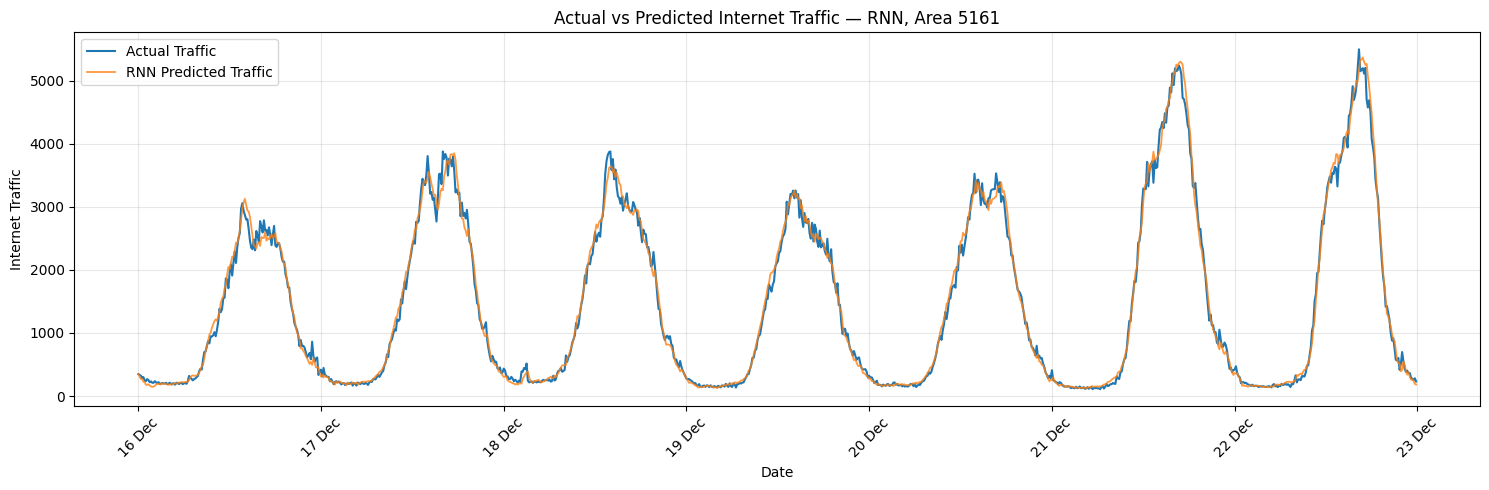

Saved: /content/drive/MyDrive/ML Techniques I/Formative 1/results/figures/RNN_5161_actual_vs_predicted.png


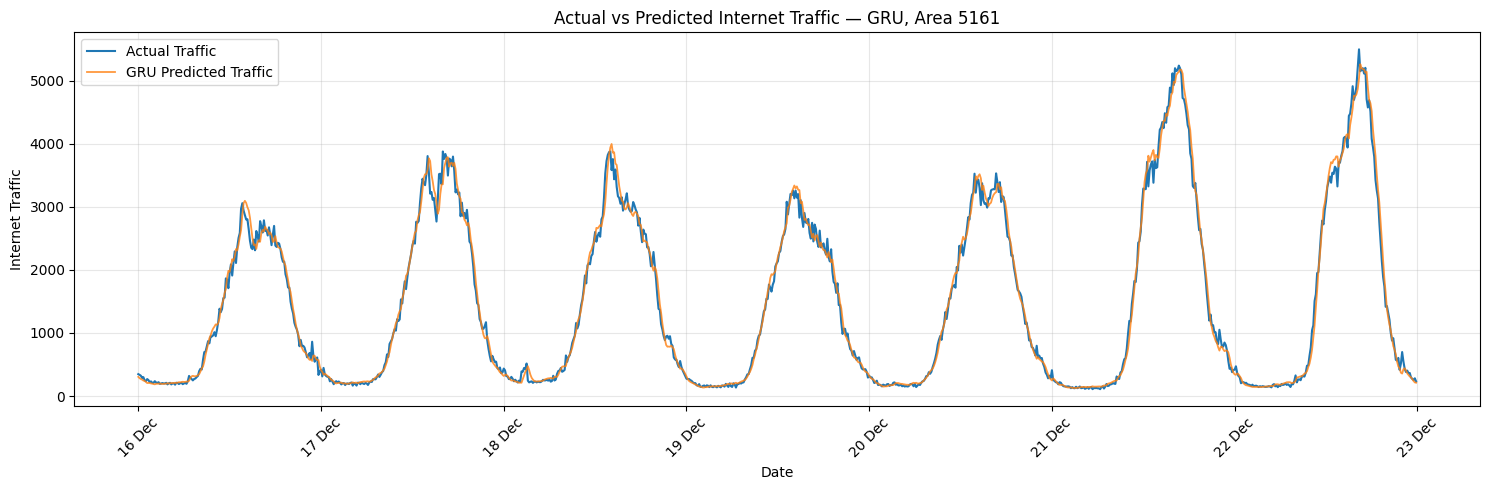

Saved: /content/drive/MyDrive/ML Techniques I/Formative 1/results/figures/GRU_5161_actual_vs_predicted.png


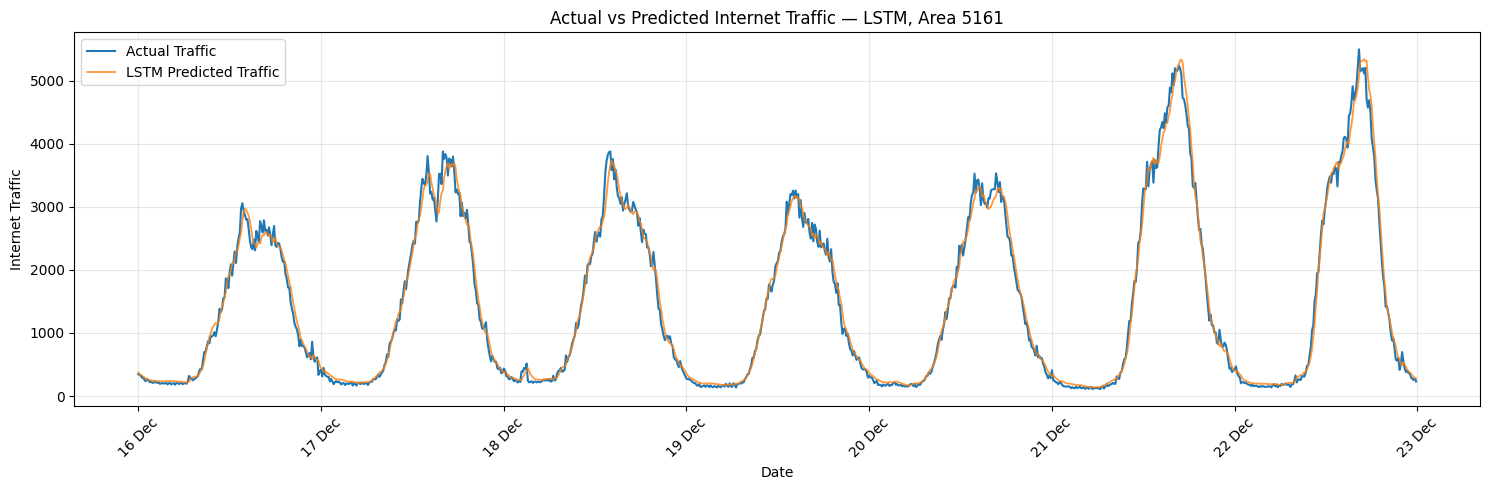

Saved: /content/drive/MyDrive/ML Techniques I/Formative 1/results/figures/LSTM_5161_actual_vs_predicted.png


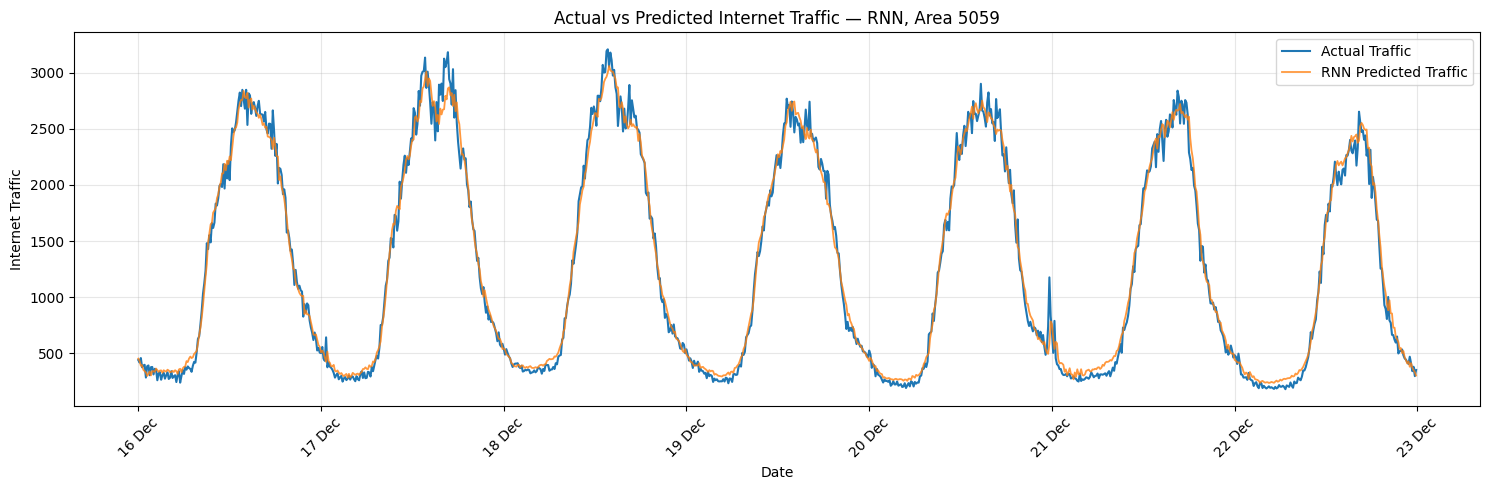

Saved: /content/drive/MyDrive/ML Techniques I/Formative 1/results/figures/RNN_5059_actual_vs_predicted.png


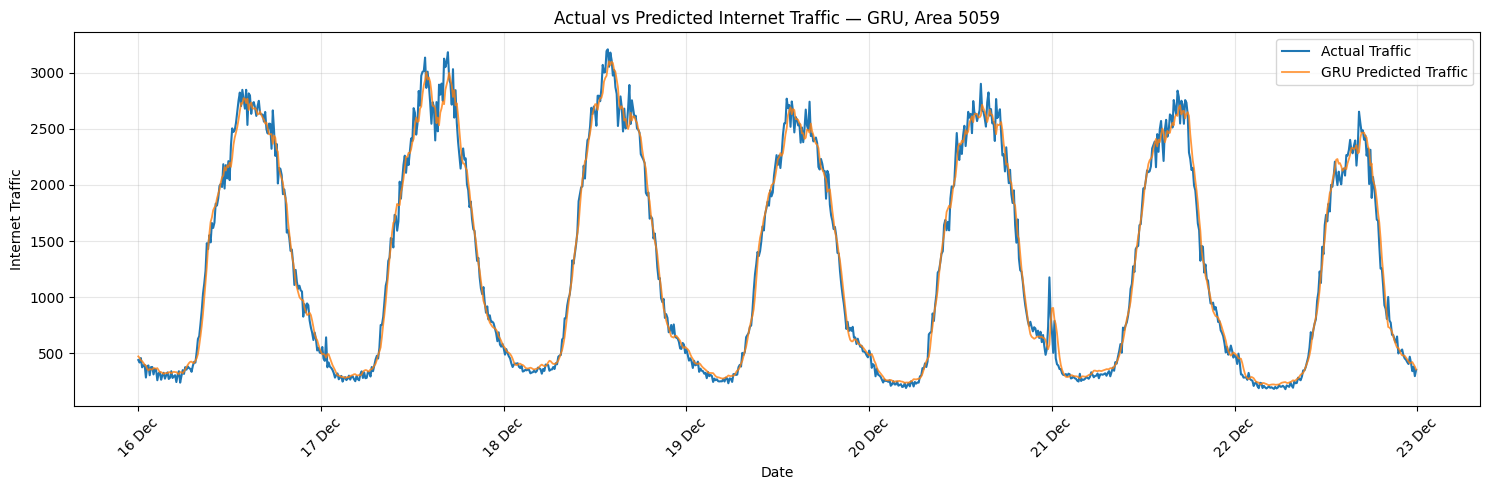

Saved: /content/drive/MyDrive/ML Techniques I/Formative 1/results/figures/GRU_5059_actual_vs_predicted.png


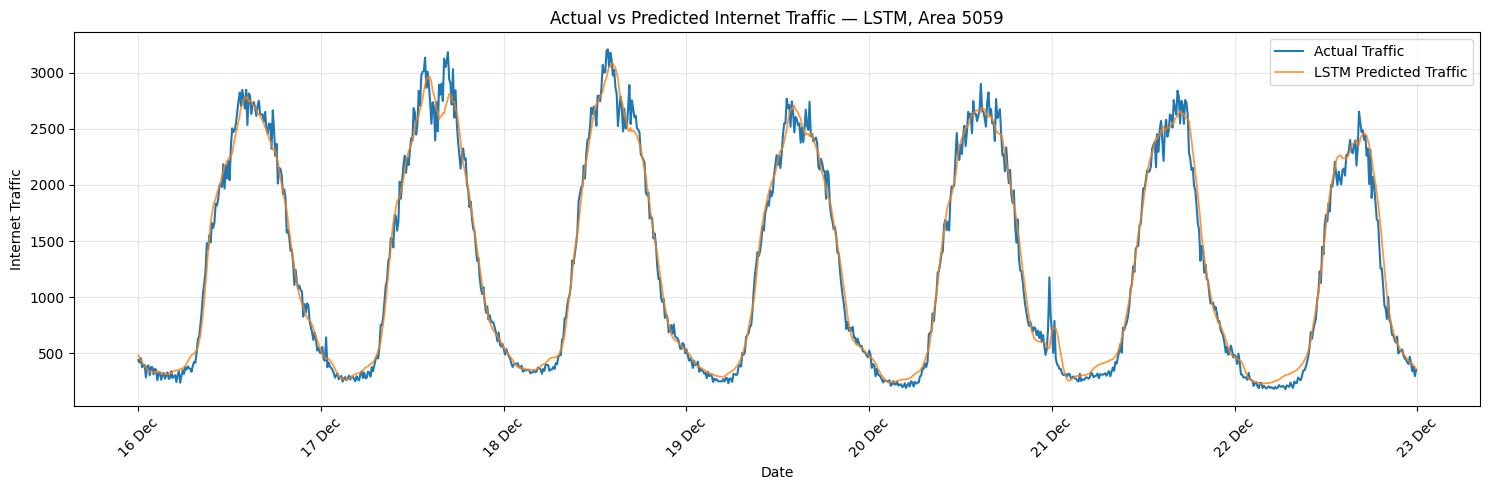

Saved: /content/drive/MyDrive/ML Techniques I/Formative 1/results/figures/LSTM_5059_actual_vs_predicted.png


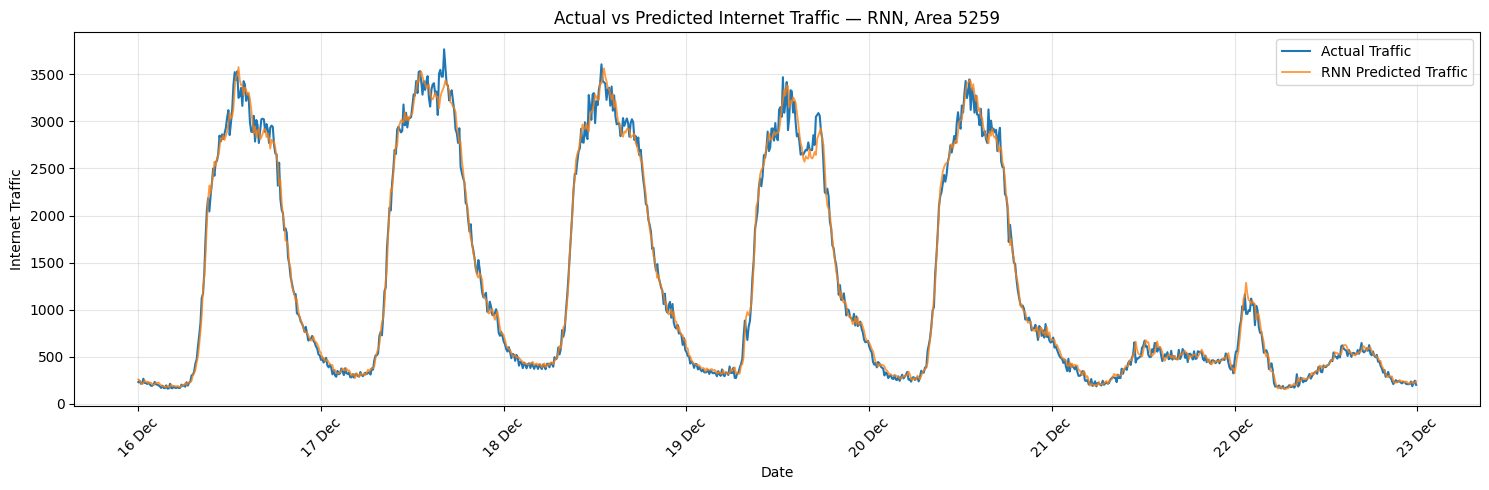

Saved: /content/drive/MyDrive/ML Techniques I/Formative 1/results/figures/RNN_5259_actual_vs_predicted.png


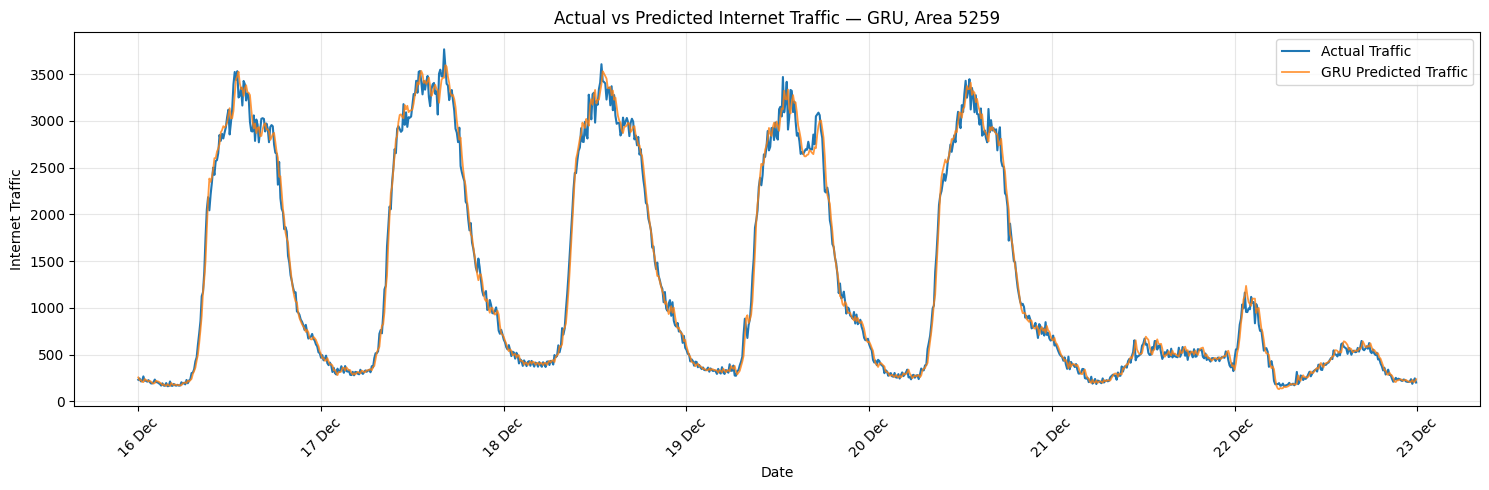

Saved: /content/drive/MyDrive/ML Techniques I/Formative 1/results/figures/GRU_5259_actual_vs_predicted.png


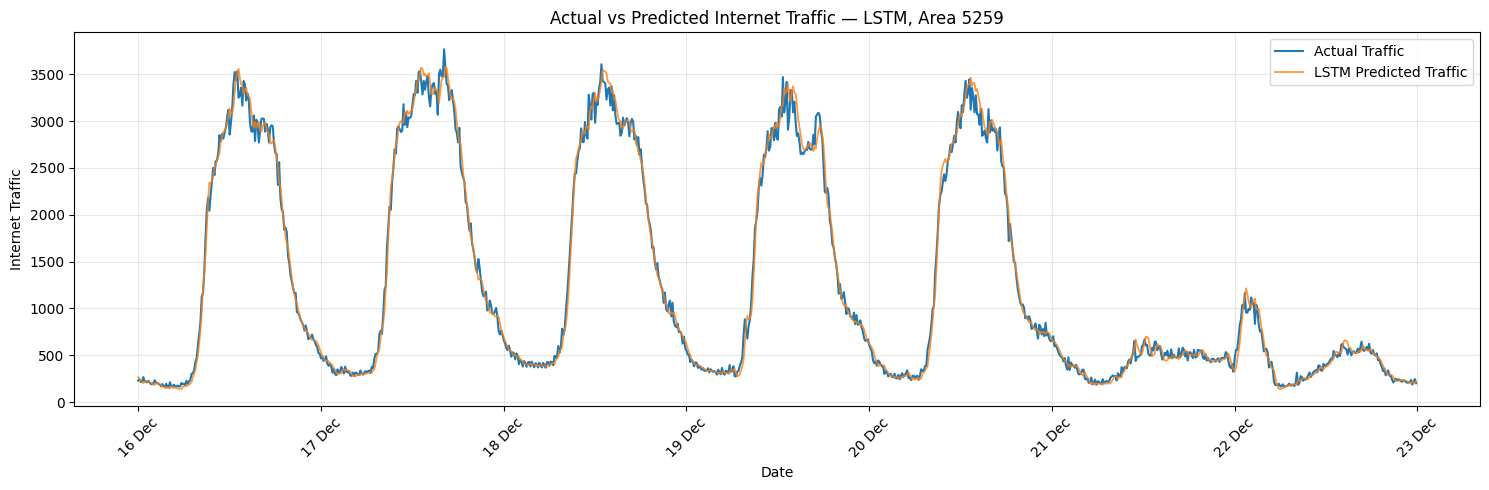

Saved: /content/drive/MyDrive/ML Techniques I/Formative 1/results/figures/LSTM_5259_actual_vs_predicted.png


In [29]:
# Folder where the 9 figures will be saved
FIGURES_DIR = "/content/drive/MyDrive/ML Techniques I/Formative 1/results/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Test period contains 1008 observations:
# 7 days × 144 observations per day
test_timestamps = pd.date_range(
    start="2013-12-16 00:00:00",
    periods=1008,
    freq="10min"
)

# Generate one plot for every model-area combination
for square_id in TARGET_SQUARES:

    # Actual traffic for this geographical area
    y_true = actuals[square_id]

    for model_type in model_types:

        # Predictions already generated during evaluation
        y_pred = predictions[square_id][model_type]

        # Create figure
        plt.figure(figsize=(15, 5))

        # plot Actual traffic & Predicted traffic
        plt.plot(test_timestamps, y_true, label="Actual Traffic", linewidth=1.5)
        plt.plot(test_timestamps, y_pred, label=f"{model_type} Predicted Traffic", linewidth=1.3, alpha=0.8)

        # Formatting
        plt.title(f"Actual vs Predicted Internet Traffic — {model_type}, Area {square_id}")
        plt.xlabel("Date")
        plt.ylabel("Internet Traffic")

        # Display one main tick per day
        ax = plt.gca()

        ax.xaxis.set_major_locator(mdates.DayLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

        plt.xticks(rotation=45)
        plt.legend()
        plt.grid(alpha=0.3)

        plt.tight_layout()

        # Save to Google Drive
        filename = (f"{model_type}_{square_id}_actual_vs_predicted.png")
        figure_path = os.path.join(FIGURES_DIR, filename)

        plt.savefig(figure_path, dpi=300, bbox_inches="tight")

        # Display figure in notebook
        plt.show()

        # Close figure to free memory
        plt.close()

        print(f"Saved: {figure_path}")

### Visual Analysis of the Forecasts

The nine actual-versus-predicted plots show that all three models capture the main temporal structure of Internet traffic reasonably well. In most cases, the predicted series closely follows the observed series throughout the test week. In particular, the models successfully reproduce the strong daily pattern, including the low-traffic periods during the night, the rapid increase in traffic during the day, and the subsequent daily peaks and declines. This indicates that using the previous 144 observations (24 hours) provides useful information for one-step-ahead forecasting.

The predictions are generally smoother than the actual traffic. This is particularly visible around sharp peaks and short-lived fluctuations, where the observed traffic contains sudden changes that the models do not always reproduce exactly. The models tend to follow the general direction and magnitude of these peaks while smoothing some of the local variability. This helps explain why the overall MAE and MAPE values are relatively low while the RMSE values are higher, since RMSE gives greater weight to occasional larger prediction errors.

Differences between the geographical areas are also clearly visible. Area 5161 presents large variations in daily peak magnitude, with particularly high traffic peaks on December 21 and 22. Nevertheless, the three models generally follow these changes closely. Area 5059 displays a more regular daily cycle, although several short and abrupt fluctuations occur around the daytime peaks. These irregular fluctuations are often smoothed by the predictions. Area 5259 shows the most noticeable change in traffic behaviour during the week: high and regular daily peaks are observed from December 16 to 20, followed by a substantial reduction in traffic on December 21 and 22. Despite this change, the models adapt well and continue to track the lower traffic levels.

The plots also support the quantitative results by showing that the differences between RNN, GRU and LSTM are relatively small visually. No architecture consistently produces visibly superior predictions across all three geographical areas. Instead, their relative performance changes depending on the area. For example, the GRU obtained the lowest MAE for areas 5161 and 5059, while the RNN obtained the lowest MAE for area 5259. This reinforces the observation that forecasting performance depends on both the model architecture and the traffic characteristics of the geographical area.

Overall, the results show that RNN, GRU and LSTM are all capable of learning the dominant daily dynamics of the traffic series and generalizing them to the unseen test week. Their main limitation appears around abrupt, short-term fluctuations and unusual peaks, where predictions tend to be smoother than the observed traffic. These periods therefore provide useful candidates for a more detailed failure analysis.